# Perguntas Analiticas - Passos Magicos Datathon

## Objetivo
Responder 11 perguntas de negocio usando o dataset limpo e unificado.

## Fonte oficial
- data/dados_unificados.csv

## Perguntas
1. Perfil e evolucao do IAN
2. Tendencia de desempenho do IDA
3. Correlacao entre IEG, IDA e IPV
4. Alinhamento entre IAA e IDA
5. Padroes de risco psicossocial (IPS)
6. Consistencia entre IAN e IPP
7. Melhores preditores de IPV
8. Combinacoes de indicadores que elevam INDE
9. Sinais precoces de risco academico
10. Evolucao de desempenho entre fases
11. Insights adicionais


In [14]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
data_path = project_root / 'data' / 'dados_unificados.csv'
if not data_path.exists():
    raise FileNotFoundError(f"Arquivo oficial nao encontrado: {data_path}")

df = pd.read_csv(data_path)

if 'year' in df.columns:
    df['ano'] = pd.to_numeric(df['year'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')
else:
    df['ano'] = np.nan

print(f'Fonte: {data_path.name}')
print(f'Shape: {df.shape[0]} linhas x {df.shape[1]} colunas')
if df['ano'].notna().any():
    anos_validos = sorted(df['ano'].dropna().astype(int).unique().tolist())
    print(f"Anos no dataset: {anos_validos}")

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
sns.set_theme(style='whitegrid')

# Paleta principal mais escura para conforto visual
COR_VERMELHO = '#8b1e1e'
COR_LARANJA = '#b35a00'
COR_VERDE = '#1f7a4c'
COR_AZUL = '#1f4e79'
COR_AZUL_CLARO = '#8bb3d9'
COR_TEXTO = '#2c3e50'
PALETA = [COR_AZUL, COR_AZUL_CLARO, COR_VERDE, COR_LARANJA, COR_VERMELHO]

fig_dir = project_root / 'outputs' / 'figuras'
fig_dir.mkdir(parents=True, exist_ok=True)

def salvar_figura(fig, nome_arquivo):
    caminho = fig_dir / nome_arquivo
    fig.savefig(caminho, dpi=150, bbox_inches='tight')
    print(f'Figura salva: {caminho.name}')

# Normalizacao de fase/turma para evitar mistura fase vs turma em agregacoes
_phase_num = re.compile(r'^\s*([0-9]{1,2})\s*$')
_phase_code = re.compile(r'^\s*([0-9]{1,2})([A-Z])\s*$', re.IGNORECASE)
_phase_text = re.compile(r'^\s*FASE\s*([0-9]{1,2})\s*$', re.IGNORECASE)
_class_alfa = re.compile(r'^\s*ALFA\s+([A-Z])\b', re.IGNORECASE)


def _parse_phase_turma(phase_val, class_val):
    p = '' if pd.isna(phase_val) else str(phase_val).strip().upper()
    c = '' if pd.isna(class_val) else str(class_val).strip().upper()

    fase, turma = np.nan, np.nan

    if p == 'ALFA' or p.startswith('ALFA '):
        fase = 'ALFA'
    else:
        m = _phase_text.match(p)
        if m:
            fase = f"FASE {int(m.group(1))}"
        else:
            m = _phase_code.match(p)
            if m:
                fase = f"FASE {int(m.group(1))}"
                turma = m.group(2)
            else:
                m = _phase_num.match(p)
                if m:
                    fase = f"FASE {int(m.group(1))}"

    if pd.isna(turma):
        if len(c) == 1 and c.isalpha():
            turma = c
        else:
            m = _phase_code.match(c)
            if m:
                turma = m.group(2)
            else:
                m = _class_alfa.match(c)
                if m:
                    turma = m.group(1)
                    if pd.isna(fase):
                        fase = 'ALFA'

    return fase, turma


def _norm_row(row):
    return _parse_phase_turma(row.get('phase', np.nan), row.get('class', np.nan))


norm = df.apply(_norm_row, axis=1, result_type='expand')
norm.columns = ['fase_padronizada', 'turma_padronizada']
df['fase_padronizada'] = norm['fase_padronizada']
df['turma_padronizada'] = norm['turma_padronizada']

if {'ano', 'phase', 'fase_padronizada'}.issubset(df.columns):
    base_phase = df.dropna(subset=['ano']).copy()
    base_phase['ano'] = base_phase['ano'].astype(int)
    print('\nChecagem de normalizacao de fase por ano:')
    chk = base_phase.groupby('ano').agg(
        phase_bruta_unicas=('phase', 'nunique'),
        fase_padronizada_unicas=('fase_padronizada', 'nunique')
    )
    print(chk)

Fonte: dados_unificados.csv
Shape: 3030 linhas x 31 colunas
Anos no dataset: [2022, 2023, 2024]

Checagem de normalizacao de fase por ano:
      phase_bruta_unicas  fase_padronizada_unicas
ano                                              
2022                   8                        8
2023                   9                        9
2024                  72                       10


## Q1: Perfil e Evolucao do IAN

**Pergunta:** Adequação do nível (IAN): qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?
Exemplo: quantos alunos estão moderadamente ou severamente defasados?

**Nota metodológica (critério usado):** o dicionário de dados não define cortes oficiais de IAN para "defasado" vs "adequado".
Para análise executiva, adotamos uma régua analítica explícita na escala 0-10:
- Severo: IAN < 5
- Moderado: 5 <= IAN < 7
- Adequado: IAN >= 7

A variável de defasagem (`deficiency`) existe apenas em 2022 nesta base; por isso ela é usada apenas como checagem pontual, não como critério comparável entre anos.

Criterio de classificacao adotado:
- Severo: IAN < 5
- Moderado: 5 <= IAN < 7
- Adequado: IAN >= 7

Distribuicao geral de categorias do IAN:
                               contagem  percentual
categoria_ian                                      
Moderadamente defasado (5-<7)      1642       54.19
Adequado (>=7)                     1343       44.32
Severamente defasado (<5)            45        1.49

Resumo do IAN por ano:
      count   mean  median    std  min   max
ano                                         
2022    860  6.424     5.0  2.390  2.5  10.0
2023   1014  7.244     5.0  2.540  2.5  10.0
2024   1156  7.684    10.0  2.504  2.5  10.0

Percentual por categoria do IAN por ano:
categoria_ian  Severamente defasado (<5)  Moderadamente defasado (5-<7)  \
ano                                                                       
2022                                3.26                          66.63   
2023                                1.38                          53.06   
2024    

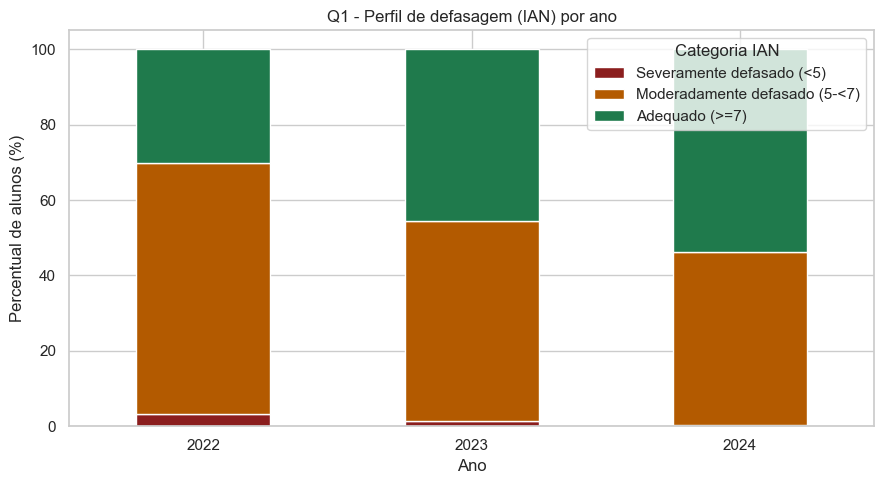

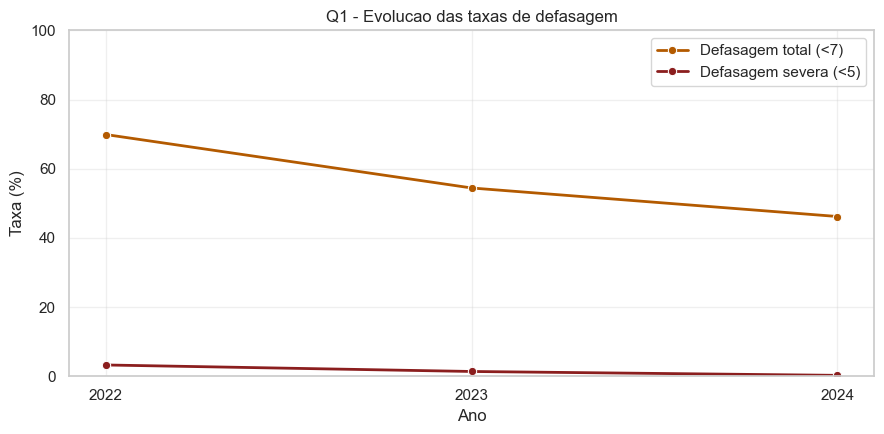

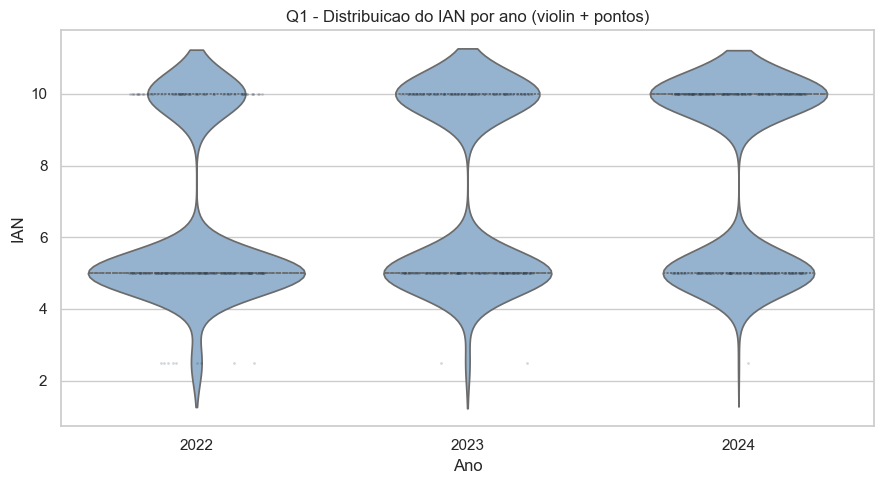


Leitura tecnica: o IAN esta bastante concentrado em poucos valores (principalmente 5 e 10),
por isso os formatos dos violins ficam visualmente parecidos entre anos; a diferenca aparece mais nas proporcoes.
Figuras salvas em: c:\Users\nykol\Python\Pós Tech\Módulo 5\fiap-datathon-fase5\outputs\figuras


In [2]:
if 'ian' not in df.columns:
    print('Coluna IAN nao encontrada.')
else:
    tmp = df.copy()
    tmp = tmp.dropna(subset=['ian', 'ano']).copy()
    tmp['ano'] = tmp['ano'].astype(int)

    # Fallback de cores caso a célula de setup não tenha sido reexecutada
    cor_vermelho = globals().get('COR_VERMELHO', '#8b1e1e')
    cor_laranja = globals().get('COR_LARANJA', '#b35a00')
    cor_verde = globals().get('COR_VERDE', '#1f7a4c')
    cor_azul_claro = globals().get('COR_AZUL_CLARO', '#8bb3d9')
    cor_texto = globals().get('COR_TEXTO', '#2c3e50')

    # Pasta de saída para figuras (facilita uso em apresentação)
    fig_dir = project_root / 'outputs' / 'figuras'
    fig_dir.mkdir(parents=True, exist_ok=True)

    # Regua analitica explicita na escala 0-10
    condicoes = [
        tmp['ian'] < 5,
        (tmp['ian'] >= 5) & (tmp['ian'] < 7),
        tmp['ian'] >= 7
    ]
    categorias = ['Severamente defasado (<5)', 'Moderadamente defasado (5-<7)', 'Adequado (>=7)']
    tmp['categoria_ian'] = np.select(condicoes, categorias, default=np.nan)

    print('Criterio de classificacao adotado:')
    print('- Severo: IAN < 5')
    print('- Moderado: 5 <= IAN < 7')
    print('- Adequado: IAN >= 7')

    dist_geral = tmp['categoria_ian'].value_counts(dropna=False).rename('contagem').to_frame()
    dist_geral['percentual'] = (dist_geral['contagem'] / dist_geral['contagem'].sum() * 100).round(2)
    print('\nDistribuicao geral de categorias do IAN:')
    print(dist_geral)

    resumo_ano = tmp.groupby('ano')['ian'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)
    print('\nResumo do IAN por ano:')
    print(resumo_ano)

    dist_ano = (
        pd.crosstab(tmp['ano'], tmp['categoria_ian'], normalize='index')
        .mul(100)
        .round(2)
        .reindex(columns=categorias)
    )
    dist_ano['Defasagem total (<7) %'] = (
        dist_ano['Severamente defasado (<5)'].fillna(0) + dist_ano['Moderadamente defasado (5-<7)'].fillna(0)
    ).round(2)
    dist_ano['Defasagem severa (<5) %'] = dist_ano['Severamente defasado (<5)'].fillna(0).round(2)

    print('\nPercentual por categoria do IAN por ano:')
    print(dist_ano)

    # Checagem pontual com coluna de defasagem oficial (apenas onde existir)
    if 'deficiency' in tmp.columns and tmp['deficiency'].notna().any():
        chk = tmp.dropna(subset=['deficiency']).copy()
        chk['defasagem_ian_analitica'] = (chk['ian'] < 7).astype(int)
        concordancia = (chk['defasagem_ian_analitica'] == chk['deficiency'].astype(int)).mean() * 100
        print(f'\nChecagem pontual (onde deficiency existe): concordancia {concordancia:.2f}%')
        print('Observacao: essa checagem nao e comparavel entre anos (deficiency so em 2022).')

    anos_ord = sorted(dist_ano.index.tolist())

    # Figura 1 (separada): perfil por categoria
    fig, ax = plt.subplots(figsize=(9, 5))
    dist_ano[categorias].plot(kind='bar', stacked=True, color=[cor_vermelho, cor_laranja, cor_verde], ax=ax)
    ax.set_title('Q1 - Perfil de defasagem (IAN) por ano')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Percentual de alunos (%)')
    ax.set_xticklabels([str(int(x)) for x in anos_ord], rotation=0)
    ax.legend(title='Categoria IAN', loc='upper right')
    fig.tight_layout()
    fig.savefig(fig_dir / 'q1_perfil_defasagem_por_ano.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Figura 2 (separada): evolucao das taxas
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.lineplot(x=dist_ano.index, y=dist_ano['Defasagem total (<7) %'], marker='o', linewidth=2, color=cor_laranja, label='Defasagem total (<7)', ax=ax)
    sns.lineplot(x=dist_ano.index, y=dist_ano['Defasagem severa (<5) %'], marker='o', linewidth=2, color=cor_vermelho, label='Defasagem severa (<5)', ax=ax)
    ax.set_title('Q1 - Evolucao das taxas de defasagem')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Taxa (%)')
    ax.set_xticks(anos_ord)
    ax.set_xticklabels([str(int(x)) for x in anos_ord])
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(fig_dir / 'q1_evolucao_taxas_defasagem.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Figura 3 (separada): distribuicao detalhada do IAN
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.violinplot(data=tmp, x='ano', y='ian', inner='quartile', color=cor_azul_claro, ax=ax)
    sns.stripplot(
        data=tmp.sample(min(len(tmp), 900), random_state=42),
        x='ano', y='ian', color=cor_texto, alpha=0.20, size=2, jitter=0.25, ax=ax
    )
    ax.set_title('Q1 - Distribuicao do IAN por ano (violin + pontos)')
    ax.set_xlabel('Ano')
    ax.set_ylabel('IAN')
    ax.set_xticklabels([str(int(x)) for x in anos_ord])
    fig.tight_layout()
    fig.savefig(fig_dir / 'q1_distribuicao_ian_violin.png', dpi=200, bbox_inches='tight')
    plt.show()

    print('\nLeitura tecnica: o IAN esta bastante concentrado em poucos valores (principalmente 5 e 10),')
    print('por isso os formatos dos violins ficam visualmente parecidos entre anos; a diferenca aparece mais nas proporcoes.')
    print(f'Figuras salvas em: {fig_dir}')

## Q2: Tendencia de Desempenho do IDA

**Pergunta:** Desempenho acadêmico (IDA): o desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

IDA por ano (com variacao anual):
      count   mean  median    std  var_ano_anterior      ci95
ano                                                          
2022    860  6.093    6.30  2.046               NaN  0.136745
2023    937  6.663    6.80  1.595             0.570  0.102129
2024   1055  6.351    6.75  2.132            -0.312  0.128652
Figura salva: q2_ida_tendencia_media_ic95.png


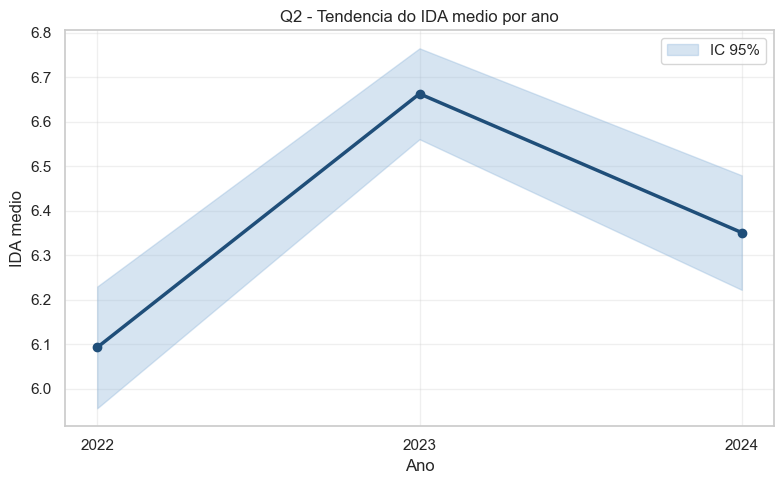

Figura salva: q2_ida_boxplot_por_ano.png


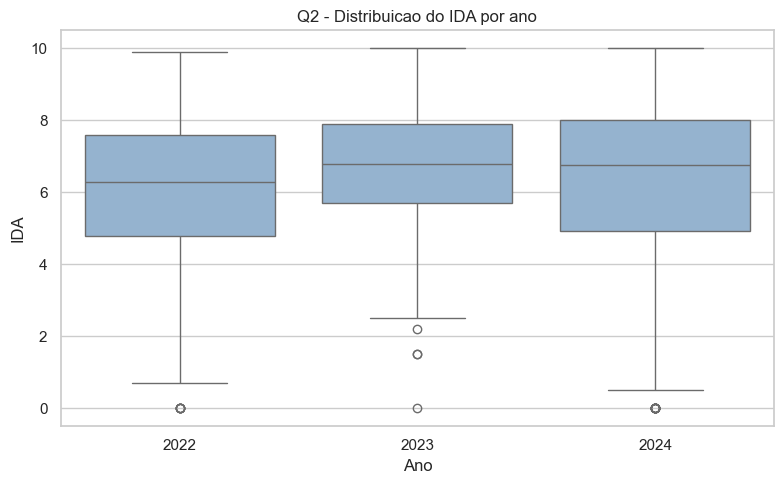


IDA por fase no ano mais recente (2024):
                  count   mean
fase_padronizada              
ALFA                196  7.320
FASE 6               25  7.230
FASE 1              185  6.791
FASE 5              100  6.453
FASE 2              185  6.250
FASE 4              115  5.879
FASE 7               37  5.810
FASE 3              211  5.348
Figura salva: q2_ida_top_fases_padronizadas_ano_recente.png


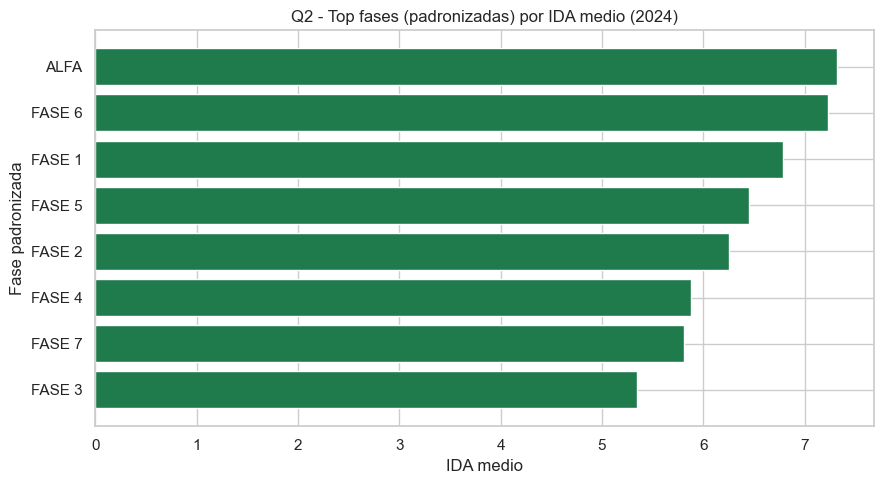


Leitura critica (Q2):
- Achado: variacao acumulada do IDA medio no periodo = +0.258.
- Impacto: houve oscilacao anual; melhoria precisa ser sustentada por fase e nao apenas no agregado.
- Acao: priorizar fases com menor IDA no ano mais recente para evitar regressao do indicador.


In [15]:
if 'ida' not in df.columns:
    print('Coluna IDA nao encontrada.')
else:
    tmp = df.copy()
    fase_col = 'fase_padronizada' if 'fase_padronizada' in tmp.columns else 'phase'

    if tmp['ano'].notna().any():
        t = tmp[tmp['ano'].notna()].copy()
        t['ano'] = t['ano'].astype(int)
        resumo = t.groupby('ano')['ida'].agg(['count', 'mean', 'median', 'std']).round(3)
        resumo['var_ano_anterior'] = resumo['mean'].diff().round(3)
        resumo['ci95'] = (1.96 * (resumo['std'] / np.sqrt(resumo['count']))).fillna(0)
        anos_plot = resumo.index.astype(int).tolist()

        print('IDA por ano (com variacao anual):')
        print(resumo)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(anos_plot, resumo['mean'].values, marker='o', linewidth=2.5, color=COR_AZUL)
        ax.fill_between(
            anos_plot,
            (resumo['mean'] - resumo['ci95']).values,
            (resumo['mean'] + resumo['ci95']).values,
            color=COR_AZUL_CLARO,
            alpha=0.35,
            label='IC 95%'
        )
        ax.set_title('Q2 - Tendencia do IDA medio por ano')
        ax.set_xlabel('Ano')
        ax.set_ylabel('IDA medio')
        ax.set_xticks(anos_plot)
        ax.set_xticklabels([str(a) for a in anos_plot])
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        salvar_figura(fig, 'q2_ida_tendencia_media_ic95.png')
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.boxplot(data=t, x='ano', y='ida', ax=ax, color=COR_AZUL_CLARO)
        ax.set_title('Q2 - Distribuicao do IDA por ano')
        ax.set_xlabel('Ano')
        ax.set_ylabel('IDA')
        ax.set_xticklabels([str(a) for a in sorted(t['ano'].dropna().astype(int).unique())])
        plt.tight_layout()
        salvar_figura(fig, 'q2_ida_boxplot_por_ano.png')
        plt.show()

        if {'ano', fase_col, 'ida'}.issubset(tmp.columns):
            t2 = tmp[tmp['ano'].notna()].copy()
            if not t2.empty:
                ano_recente = int(t2['ano'].max())
                fase_ida = (
                    t2[(t2['ano'] == ano_recente) & (t2[fase_col].notna())]
                    .groupby(fase_col)['ida']
                    .agg(['count', 'mean'])
                    .query('count >= 10')
                    .sort_values('mean', ascending=False)
                    .round(3)
                )
                print(f'\nIDA por fase no ano mais recente ({ano_recente}):')
                if fase_ida.empty:
                    print('Sem volume minimo por fase (count >= 10) no ano mais recente.')
                else:
                    print(fase_ida)

                    top_fases = fase_ida.head(10).sort_values('mean')
                    fig, ax = plt.subplots(figsize=(9, 5))
                    ax.barh(top_fases.index.astype(str), top_fases['mean'], color=COR_VERDE)
                    ax.set_title(f'Q2 - Top fases (padronizadas) por IDA medio ({ano_recente})')
                    ax.set_xlabel('IDA medio')
                    ax.set_ylabel('Fase')
                    plt.tight_layout()
                    salvar_figura(fig, 'q2_ida_top_fases_padronizadas_ano_recente.png')
                    plt.show()

        variacao_total = resumo['mean'].iloc[-1] - resumo['mean'].iloc[0]
        print('\nLeitura critica (Q2):')
        print(f'- Achado: variacao acumulada do IDA medio no periodo = {variacao_total:+.3f}.')
        print('- Impacto: houve oscilacao anual; melhoria precisa ser sustentada por fase e nao apenas no agregado.')
        print('- Acao: priorizar fases com menor IDA no ano mais recente para evitar regressao do indicador.')

## Q3: Correlacao entre IEG, IDA e IPV

**Pergunta:** Engajamento nas atividades (IEG): o grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

Correlacao geral:
       ieg    ida    ipv
ieg  1.000  0.539  0.558
ida  0.539  1.000  0.557
ipv  0.558  0.557  1.000

Correlacao por ano (IEG x IDA, IEG x IPV):
      corr_ieg_ida  corr_ieg_ipv       n
ano                                     
2022         0.564         0.589   860.0
2023         0.461         0.448   937.0
2024         0.547         0.535  1054.0

IC95 IEG x IDA: [0.517, 0.569]
IC95 IEG x IPV: [0.532, 0.583]
Figura salva: q3_heatmap_correlacoes.png


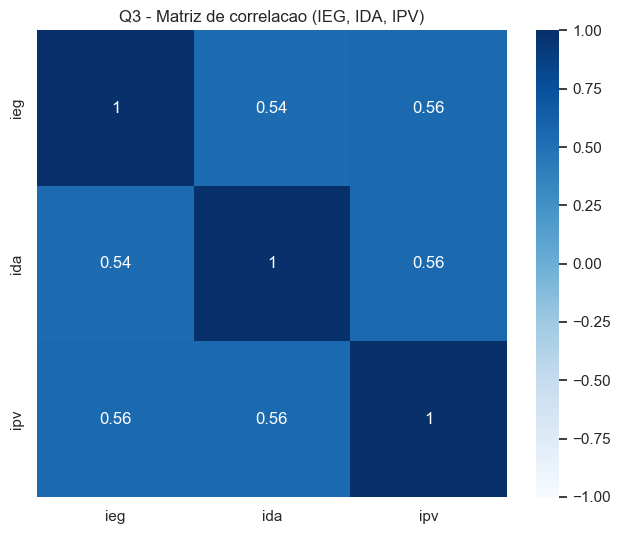

Figura salva: q3_scatter_ieg_ida_por_ano.png


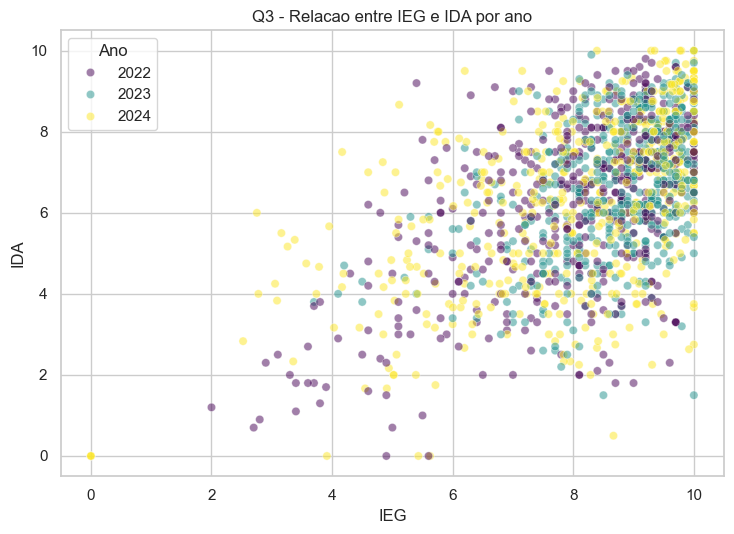

Figura salva: q3_tendencia_correlacoes_anuais.png


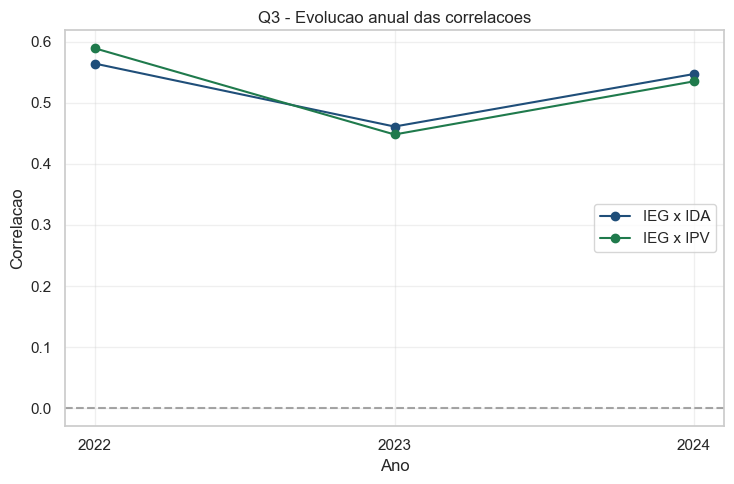


Leitura critica (Q3):
- Achado: IEG x IDA = 0.543 e IEG x IPV = 0.558, ambas associacoes positivas.
- Impacto: engajamento funciona como alavanca transversal de desempenho e ponto de virada.
- Acao: fortalecer trilhas de presenca/participacao nas fases com correlacao mais baixa.


In [4]:
def fisher_ci(r, n, alpha=0.05):
    if n <= 3 or pd.isna(r) or abs(r) >= 1:
        return (np.nan, np.nan)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = 1.96
    lo, hi = z - z_crit * se, z + z_crit * se
    return (float(np.tanh(lo)), float(np.tanh(hi)))

cols = [c for c in ['ieg', 'ida', 'ipv'] if c in df.columns]
if len(cols) < 2:
    print('Colunas insuficientes para correlacao.')
else:
    corr = df[cols].corr(numeric_only=True).round(3)
    print('Correlacao geral:')
    print(corr)

    if {'ano', 'ieg', 'ida', 'ipv'}.issubset(df.columns):
        tmp = df.dropna(subset=['ano', 'ieg', 'ida', 'ipv']).copy()
        if not tmp.empty:
            tmp['ano'] = tmp['ano'].astype(int)
            print('\nCorrelacao por ano (IEG x IDA, IEG x IPV):')
            corr_ano = tmp.groupby('ano').apply(
                lambda g: pd.Series({
                    'corr_ieg_ida': g['ieg'].corr(g['ida']),
                    'corr_ieg_ipv': g['ieg'].corr(g['ipv']),
                    'n': len(g)
                })
            ).round(3)
            print(corr_ano)

            r_ida = tmp['ieg'].corr(tmp['ida'])
            r_ipv = tmp['ieg'].corr(tmp['ipv'])
            ci_ida = fisher_ci(r_ida, len(tmp))
            ci_ipv = fisher_ci(r_ipv, len(tmp))
            print(f"\nIC95 IEG x IDA: [{ci_ida[0]:.3f}, {ci_ida[1]:.3f}]")
            print(f"IC95 IEG x IPV: [{ci_ipv[0]:.3f}, {ci_ipv[1]:.3f}]")

            fig, ax = plt.subplots(figsize=(6.5, 5.5))
            sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, ax=ax)
            ax.set_title('Q3 - Matriz de correlacao (IEG, IDA, IPV)')
            plt.tight_layout()
            salvar_figura(fig, 'q3_heatmap_correlacoes.png')
            plt.show()

            fig, ax = plt.subplots(figsize=(7.5, 5.5))
            sns.scatterplot(
                data=tmp.sample(min(len(tmp), 1500), random_state=42),
                x='ieg', y='ida', hue='ano', palette='viridis', alpha=0.5, ax=ax
            )
            ax.set_title('Q3 - Relacao entre IEG e IDA por ano')
            ax.set_xlabel('IEG')
            ax.set_ylabel('IDA')
            ax.legend(title='Ano')
            plt.tight_layout()
            salvar_figura(fig, 'q3_scatter_ieg_ida_por_ano.png')
            plt.show()

            anos_plot = corr_ano.index.astype(int).tolist()
            fig, ax = plt.subplots(figsize=(7.5, 5))
            ax.plot(anos_plot, corr_ano['corr_ieg_ida'].values, marker='o', color=COR_AZUL, label='IEG x IDA')
            ax.plot(anos_plot, corr_ano['corr_ieg_ipv'].values, marker='o', color=COR_VERDE, label='IEG x IPV')
            ax.axhline(0, linestyle='--', color='gray', alpha=0.7)
            ax.set_title('Q3 - Evolucao anual das correlacoes')
            ax.set_xlabel('Ano')
            ax.set_ylabel('Correlacao')
            ax.set_xticks(anos_plot)
            ax.set_xticklabels([str(a) for a in anos_plot])
            ax.legend()
            ax.grid(alpha=0.3)
            plt.tight_layout()
            salvar_figura(fig, 'q3_tendencia_correlacoes_anuais.png')
            plt.show()

            print('\nLeitura critica (Q3):')
            print(f'- Achado: IEG x IDA = {r_ida:.3f} e IEG x IPV = {r_ipv:.3f}, ambas associacoes positivas.')
            print('- Impacto: engajamento funciona como alavanca transversal de desempenho e ponto de virada.')
            print('- Acao: fortalecer trilhas de presenca/participacao nas fases com correlacao mais baixa.')

## Q4: Alinhamento entre IAA e IDA

**Pergunta:** Autoavaliação (IAA): as percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

Registros validos: 2851
Correlacao IAA x IDA: 0.115
Alunos com IAA >= IDA + 1 (superestimacao): 66.26%
Alunos com IAA <= IDA - 1 (subestimacao): 11.82%
Alinhamento aproximado (|IAA-IDA| < 1): 21.92%
Figura salva: q4_scatter_iaa_ida.png


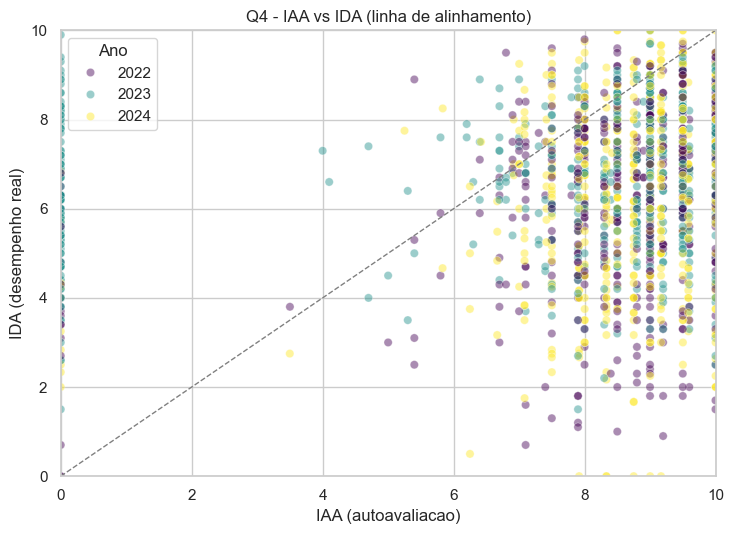

Figura salva: q4_hist_gap_autopercepcao.png


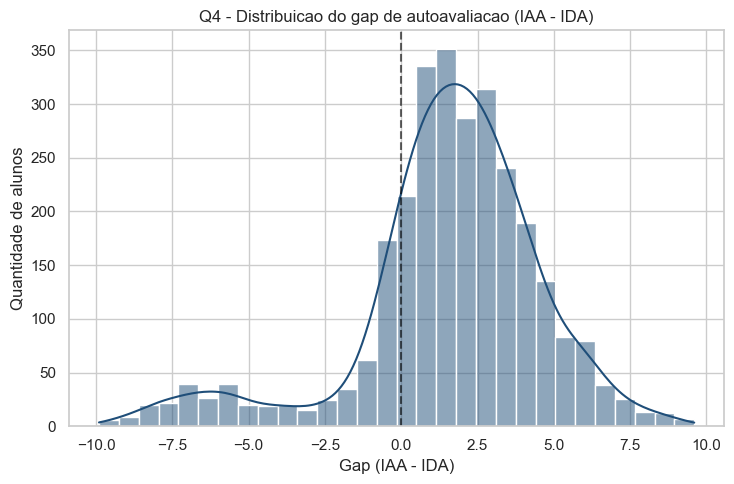

Figura salva: q4_gap_medio_por_ano.png


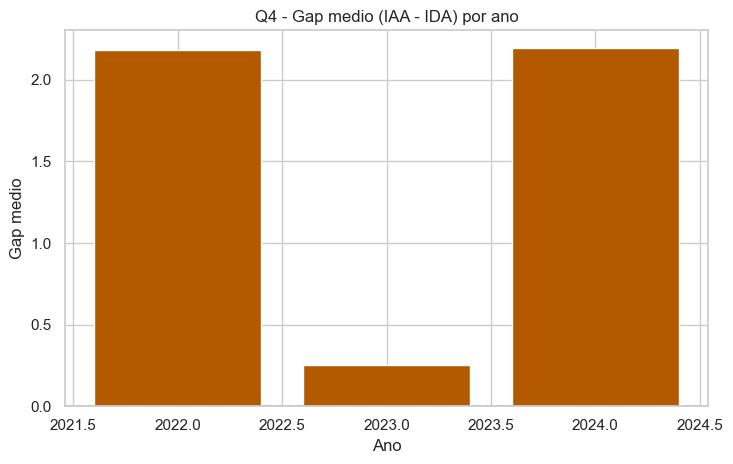


Leitura critica (Q4):
- Achado: baixa associacao entre autoavaliacao e desempenho real, com predominio de superestimacao.
- Impacto: risco de planejamento pedagogico baseado em autopercepcao inflada.
- Acao: combinar devolutiva de desempenho com mentoria para calibracao de expectativa.


In [5]:
if {'iaa', 'ida'}.issubset(df.columns):
    sub = df[['iaa', 'ida', 'ano']].dropna().copy()
    print(f'Registros validos: {len(sub)}')

    corr = sub['iaa'].corr(sub['ida'])
    print(f'Correlacao IAA x IDA: {corr:.3f}')

    sub['gap_autopercepcao'] = (sub['iaa'] - sub['ida']).round(3)
    pct_superestima = (sub['gap_autopercepcao'] >= 1).mean() * 100
    pct_subestima = (sub['gap_autopercepcao'] <= -1).mean() * 100
    pct_alinhado = (sub['gap_autopercepcao'].abs() < 1).mean() * 100
    print(f'Alunos com IAA >= IDA + 1 (superestimacao): {pct_superestima:.2f}%')
    print(f'Alunos com IAA <= IDA - 1 (subestimacao): {pct_subestima:.2f}%')
    print(f'Alinhamento aproximado (|IAA-IDA| < 1): {pct_alinhado:.2f}%')

    amostra = sub.sample(min(len(sub), 1500), random_state=42)
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    sns.scatterplot(data=amostra, x='iaa', y='ida', hue='ano', palette='viridis', alpha=0.45, ax=ax)
    ax.plot([0, 10], [0, 10], '--', color='gray', linewidth=1)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_title('Q4 - IAA vs IDA (linha de alinhamento)')
    ax.set_xlabel('IAA (autoavaliacao)')
    ax.set_ylabel('IDA (desempenho real)')
    ax.legend(title='Ano')
    plt.tight_layout()
    salvar_figura(fig, 'q4_scatter_iaa_ida.png')
    plt.show()

    fig, ax = plt.subplots(figsize=(7.5, 5))
    sns.histplot(sub['gap_autopercepcao'], bins=30, kde=True, color=COR_AZUL, ax=ax)
    ax.axvline(0, linestyle='--', color='black', alpha=0.6)
    ax.set_title('Q4 - Distribuicao do gap de autoavaliacao (IAA - IDA)')
    ax.set_xlabel('Gap (IAA - IDA)')
    ax.set_ylabel('Quantidade de alunos')
    plt.tight_layout()
    salvar_figura(fig, 'q4_hist_gap_autopercepcao.png')
    plt.show()

    if sub['ano'].notna().any():
        gap_ano = sub.groupby('ano')['gap_autopercepcao'].mean().sort_index()
        fig, ax = plt.subplots(figsize=(7.5, 4.8))
        ax.bar(gap_ano.index.astype(int), gap_ano.values, color=COR_LARANJA)
        ax.axhline(0, linestyle='--', color='gray', alpha=0.7)
        ax.set_title('Q4 - Gap medio (IAA - IDA) por ano')
        ax.set_xlabel('Ano')
        ax.set_ylabel('Gap medio')
        plt.tight_layout()
        salvar_figura(fig, 'q4_gap_medio_por_ano.png')
        plt.show()

    print('\nLeitura critica (Q4):')
    print('- Achado: baixa associacao entre autoavaliacao e desempenho real, com predominio de superestimacao.')
    print('- Impacto: risco de planejamento pedagogico baseado em autopercepcao inflada.')
    print('- Acao: combinar devolutiva de desempenho com mentoria para calibracao de expectativa.')
else:
    print('Colunas IAA/IDA nao disponiveis.')

## Q5: Padroes de Risco Psicossocial (IPS)

**Pergunta:** Aspectos psicossociais (IPS): há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

Distribuicao por quartis de IPS:
quartil_ips
Q2    1136
Q1     731
Q3     528
Q4     464
Name: count, dtype: int64

IDA medio por quartil de IPS:
quartil_ips
Q1    6.259
Q2    6.206
Q3    6.530
Q4    6.807
Name: ida, dtype: float64

IEG medio por quartil de IPS:
quartil_ips
Q1    8.321
Q2    8.042
Q3    8.235
Q4    8.536
Name: ieg, dtype: float64

IPV medio por quartil de IPS:
quartil_ips
Q1    7.623
Q2    7.373
Q3    7.431
Q4    7.981
Name: ipv, dtype: float64

Spearman (IPS x IDA): 0.085
Figura salva: q5_ida_media_por_quartil_ips.png


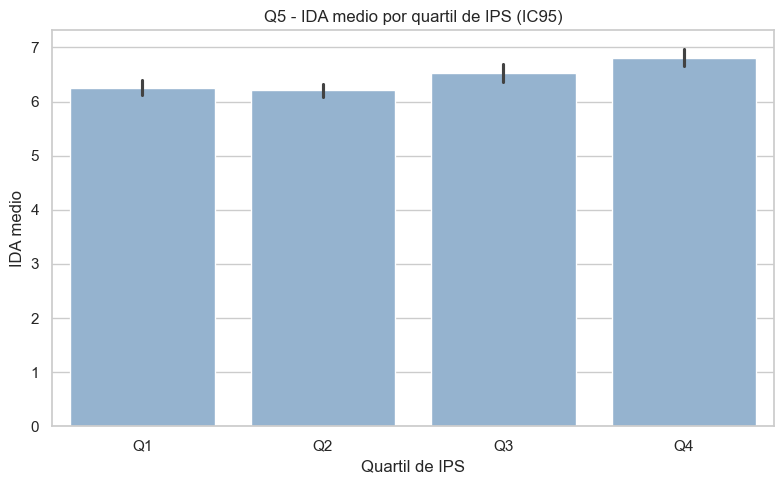

Figura salva: q5_boxplot_ida_por_quartil_ips.png


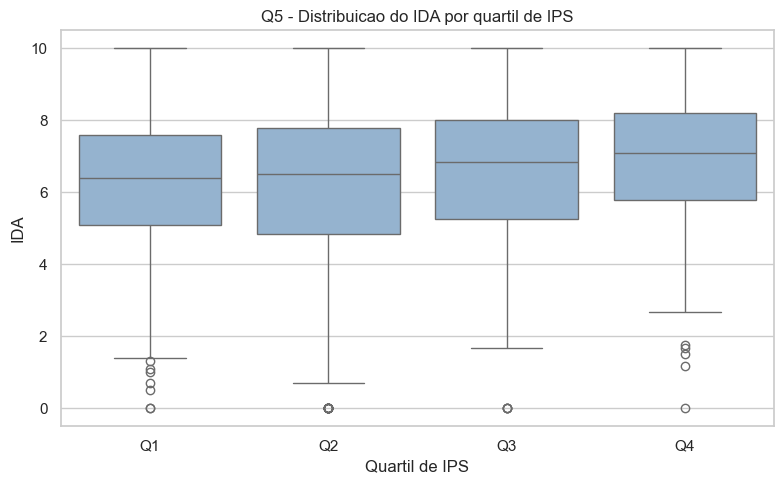

Figura salva: q5_ieg_ipv_por_quartil_ips.png


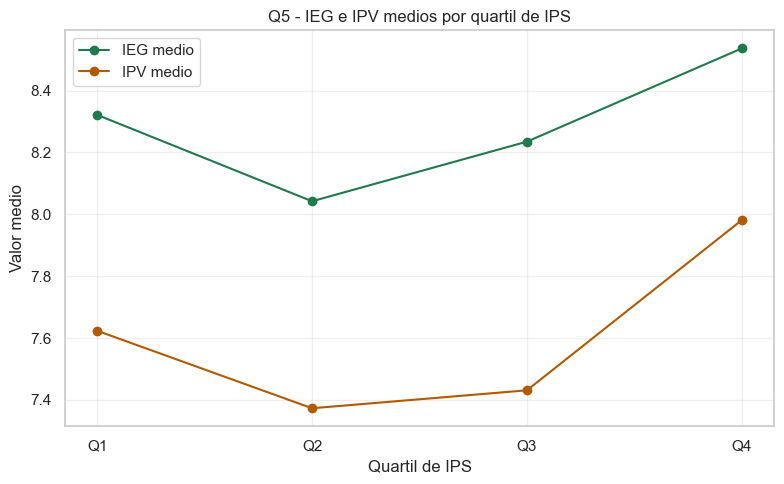


Leitura critica (Q5):
- Achado: quartis mais altos de IPS tendem a apresentar melhores medias de desempenho/engajamento.
- Impacto: IPS baixo sinaliza vulnerabilidade academica e de participacao.
- Acao: usar IPS como trigger de apoio psicossocial preventivo nas fases iniciais.


In [6]:
if 'ips' in df.columns:
    tmp = df.copy().dropna(subset=['ips'])
    q = min(4, tmp['ips'].nunique())
    if q < 2:
        print('Variabilidade insuficiente de IPS para segmentacao.')
    else:
        labels = [f'Q{i+1}' for i in range(q)]
        tmp['quartil_ips'] = pd.qcut(tmp['ips'], q=q, labels=labels, duplicates='drop')

        print('Distribuicao por quartis de IPS:')
        print(tmp['quartil_ips'].value_counts(dropna=False))

        metricas = {}
        for alvo in ['ida', 'ieg', 'ipv']:
            if alvo in tmp.columns:
                metricas[alvo] = tmp.groupby('quartil_ips', observed=False)[alvo].mean().round(3)
                print(f'\n{alvo.upper()} medio por quartil de IPS:')
                print(metricas[alvo])

        if 'ida' in tmp.columns:
            rho = tmp[['ips', 'ida']].corr(method='spearman').iloc[0, 1]
            print(f'\nSpearman (IPS x IDA): {rho:.3f}')

            fig, ax = plt.subplots(figsize=(8, 5))
            sns.barplot(data=tmp, x='quartil_ips', y='ida', estimator=np.mean, errorbar=('ci', 95), color=COR_AZUL_CLARO, ax=ax)
            ax.set_title('Q5 - IDA medio por quartil de IPS (IC95)')
            ax.set_xlabel('Quartil de IPS')
            ax.set_ylabel('IDA medio')
            plt.tight_layout()
            salvar_figura(fig, 'q5_ida_media_por_quartil_ips.png')
            plt.show()

            fig, ax = plt.subplots(figsize=(8, 5))
            sns.boxplot(data=tmp, x='quartil_ips', y='ida', color=COR_AZUL_CLARO, ax=ax)
            ax.set_title('Q5 - Distribuicao do IDA por quartil de IPS')
            ax.set_xlabel('Quartil de IPS')
            ax.set_ylabel('IDA')
            plt.tight_layout()
            salvar_figura(fig, 'q5_boxplot_ida_por_quartil_ips.png')
            plt.show()

        if {'ieg', 'ipv'}.issubset(tmp.columns):
            resumo = (
                tmp.groupby('quartil_ips', observed=False)[['ieg', 'ipv']]
                .mean()
                .reset_index()
            )
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.plot(resumo['quartil_ips'].astype(str), resumo['ieg'], marker='o', color=COR_VERDE, label='IEG medio')
            ax.plot(resumo['quartil_ips'].astype(str), resumo['ipv'], marker='o', color=COR_LARANJA, label='IPV medio')
            ax.set_title('Q5 - IEG e IPV medios por quartil de IPS')
            ax.set_xlabel('Quartil de IPS')
            ax.set_ylabel('Valor medio')
            ax.legend()
            ax.grid(alpha=0.3)
            plt.tight_layout()
            salvar_figura(fig, 'q5_ieg_ipv_por_quartil_ips.png')
            plt.show()

        print('\nLeitura critica (Q5):')
        print('- Achado: quartis mais altos de IPS tendem a apresentar melhores medias de desempenho/engajamento.')
        print('- Impacto: IPS baixo sinaliza vulnerabilidade academica e de participacao.')
        print('- Acao: usar IPS como trigger de apoio psicossocial preventivo nas fases iniciais.')
else:
    print('Coluna IPS nao encontrada.')

## Q6: Consistencia entre IAN e IPP

**Pergunta:** Aspectos psicopedagógicos (IPP): as avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

Registros validos (IAN e IPP): 1992
Correlacao IAN x IPP: 0.123

Distribuicao percentual de IPP por faixa de IAN:
ipp_faixa    Baixo (<=5)  Medio (5-7]  Alto (>7)
ian_faixa                                       
Baixo (<=5)         2.77        23.34      73.89
Alto (>7)           0.99        16.19      82.82
Concordancia direta entre faixas IAN e IPP: 39.26%
Figura salva: q6_regressao_ian_ipp.png


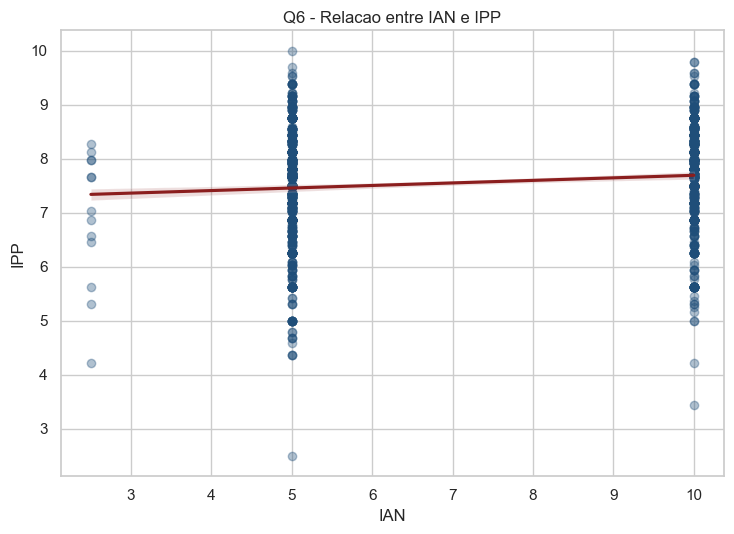

Figura salva: q6_heatmap_consistencia_ian_ipp.png


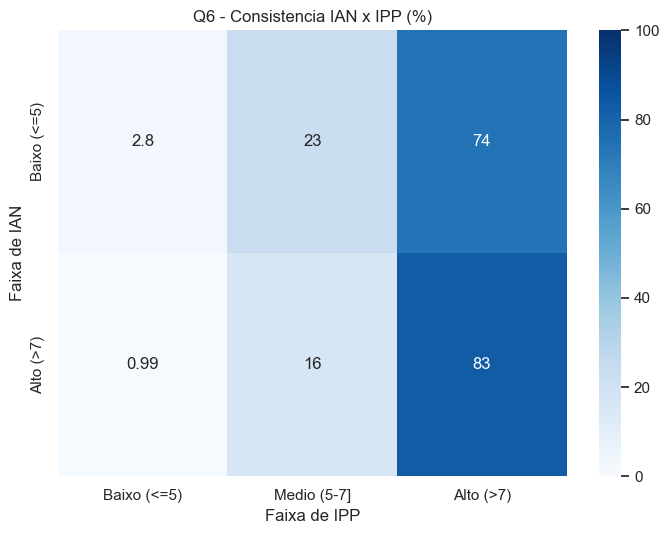

Figura salva: q6_barras_ipp_por_faixa_ian.png


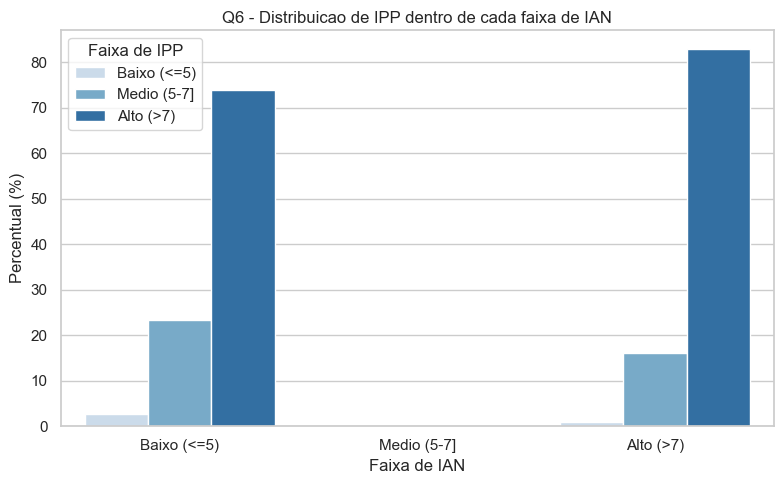


Leitura critica (Q6):
- Achado: a associacao IAN x IPP e fraca, com baixa concordancia direta entre faixas.
- Impacto: os instrumentos capturam dimensoes diferentes do risco educacional.
- Acao: combinar IAN e IPP em regra composta para triagem mais sensivel.


In [7]:
if {'ian', 'ipp'}.issubset(df.columns):
    sub = df[['ian', 'ipp', 'ano']].dropna().copy()
    print(f'Registros validos (IAN e IPP): {len(sub)}')
    corr = sub['ian'].corr(sub['ipp'])
    print(f'Correlacao IAN x IPP: {corr:.3f}')

    sub['ian_faixa'] = pd.cut(sub['ian'], bins=[-np.inf, 5, 7, np.inf], labels=['Baixo (<=5)', 'Medio (5-7]', 'Alto (>7)'])
    sub['ipp_faixa'] = pd.cut(sub['ipp'], bins=[-np.inf, 5, 7, np.inf], labels=['Baixo (<=5)', 'Medio (5-7]', 'Alto (>7)'])

    tabela = pd.crosstab(sub['ian_faixa'], sub['ipp_faixa'], normalize='index').mul(100).round(2)
    concordancia = (sub['ian_faixa'] == sub['ipp_faixa']).mean() * 100
    print('\nDistribuicao percentual de IPP por faixa de IAN:')
    print(tabela)
    print(f'Concordancia direta entre faixas IAN e IPP: {concordancia:.2f}%')

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    sns.regplot(
        data=sub.sample(min(len(sub), 1500), random_state=42),
        x='ian', y='ipp',
        scatter_kws={'alpha': 0.35, 'color': COR_AZUL},
        line_kws={'color': COR_VERMELHO},
        ax=ax
    )
    ax.set_title('Q6 - Relacao entre IAN e IPP')
    ax.set_xlabel('IAN')
    ax.set_ylabel('IPP')
    plt.tight_layout()
    salvar_figura(fig, 'q6_regressao_ian_ipp.png')
    plt.show()

    fig, ax = plt.subplots(figsize=(7.2, 5.5))
    sns.heatmap(tabela, annot=True, cmap='Blues', vmin=0, vmax=100, ax=ax)
    ax.set_title('Q6 - Consistencia IAN x IPP (%)')
    ax.set_xlabel('Faixa de IPP')
    ax.set_ylabel('Faixa de IAN')
    plt.tight_layout()
    salvar_figura(fig, 'q6_heatmap_consistencia_ian_ipp.png')
    plt.show()

    dist = pd.crosstab(sub['ian_faixa'], sub['ipp_faixa'], normalize='index').mul(100)
    dist_plot = dist.reset_index().melt(id_vars='ian_faixa', var_name='ipp_faixa', value_name='pct')
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=dist_plot, x='ian_faixa', y='pct', hue='ipp_faixa', palette='Blues', ax=ax)
    ax.set_title('Q6 - Distribuicao de IPP dentro de cada faixa de IAN')
    ax.set_xlabel('Faixa de IAN')
    ax.set_ylabel('Percentual (%)')
    ax.legend(title='Faixa de IPP')
    plt.tight_layout()
    salvar_figura(fig, 'q6_barras_ipp_por_faixa_ian.png')
    plt.show()

    print('\nLeitura critica (Q6):')
    print('- Achado: a associacao IAN x IPP e fraca, com baixa concordancia direta entre faixas.')
    print('- Impacto: os instrumentos capturam dimensoes diferentes do risco educacional.')
    print('- Acao: combinar IAN e IPP em regra composta para triagem mais sensivel.')
else:
    print('Colunas IAN/IPP nao disponiveis.')

## Q7: Melhores Preditores do IPV

**Pergunta:** Ponto de virada (IPV): quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?

Top 10 associacoes (Spearman absoluto) com IPV:
inde_2024     0.753
inde_2022     0.621
ipp           0.596
inde_2023     0.571
ida           0.562
ieg           0.546
portuguese    0.502
english       0.487
math          0.456
birth_year    0.219
Name: ipv, dtype: float64
Figura salva: q7_top10_associacoes_ipv.png


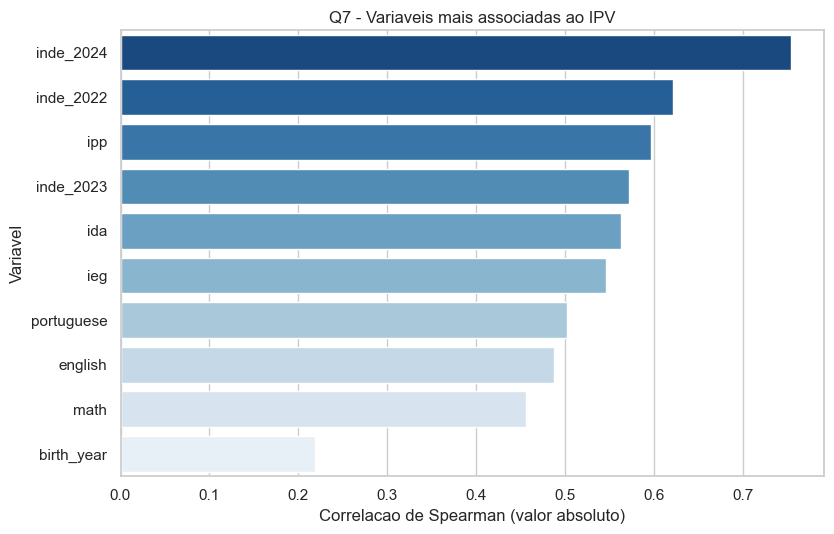

Figura salva: q7_scatter_principal_preditor_ipv.png


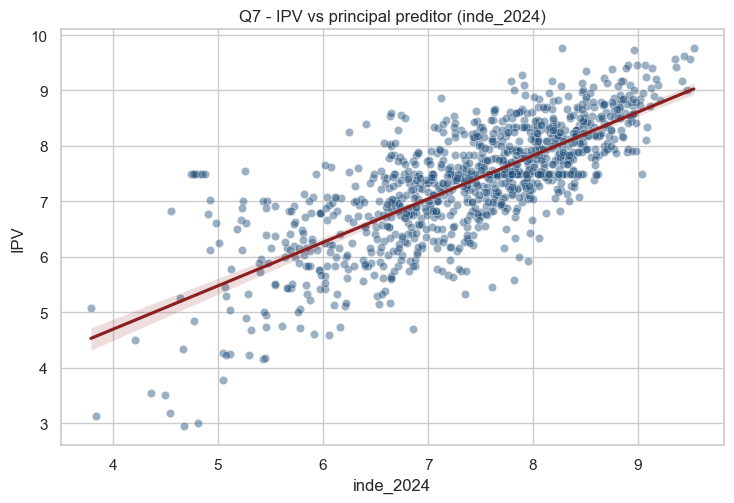


Leitura critica (Q7):
- Achado: principal associacao com IPV = inde_2024 (0.753).
- Impacto: variavel lider pode orientar monitoramento continuo do ponto de virada.
- Acao: incorporar top preditores no painel de risco para alertas antecipados.


In [8]:
if 'ipv' not in df.columns:
    print('Coluna IPV nao encontrada.')
else:
    num = [c for c in df.select_dtypes(include='number').columns if c not in ['ipv', 'ano']]
    if not num:
        print('Nao ha colunas numericas para comparacao.')
    else:
        corr_abs = (
            df[num + ['ipv']]
            .corr(method='spearman', numeric_only=True)['ipv']
            .drop('ipv')
            .abs()
            .sort_values(ascending=False)
        )
        top10 = corr_abs.head(10).round(3)
        print('Top 10 associacoes (Spearman absoluto) com IPV:')
        print(top10)

        fig, ax = plt.subplots(figsize=(8.5, 5.5))
        sns.barplot(x=top10.values, y=top10.index, palette='Blues_r', ax=ax)
        ax.set_title('Q7 - Variaveis mais associadas ao IPV')
        ax.set_xlabel('Correlacao de Spearman (valor absoluto)')
        ax.set_ylabel('Variavel')
        plt.tight_layout()
        salvar_figura(fig, 'q7_top10_associacoes_ipv.png')
        plt.show()

        principal = top10.index[0]
        amostra = df[[principal, 'ipv']].dropna()
        if not amostra.empty:
            fig, ax = plt.subplots(figsize=(7.5, 5.2))
            sns.scatterplot(
                data=amostra.sample(min(len(amostra), 1500), random_state=42),
                x=principal,
                y='ipv',
                color=COR_AZUL,
                alpha=0.45,
                ax=ax
            )
            sns.regplot(
                data=amostra,
                x=principal,
                y='ipv',
                scatter=False,
                color=COR_VERMELHO,
                ax=ax
            )
            ax.set_title(f'Q7 - IPV vs principal preditor ({principal})')
            ax.set_xlabel(principal)
            ax.set_ylabel('IPV')
            plt.tight_layout()
            salvar_figura(fig, 'q7_scatter_principal_preditor_ipv.png')
            plt.show()

        print('\nLeitura critica (Q7):')
        print(f'- Achado: principal associacao com IPV = {principal} ({top10.iloc[0]:.3f}).')
        print('- Impacto: variavel lider pode orientar monitoramento continuo do ponto de virada.')
        print('- Acao: incorporar top preditores no painel de risco para alertas antecipados.')

## Q8: Combinacoes que Elevam o INDE

**Pergunta:** Multidimensionalidade dos indicadores: quais combinações de indicadores (IDA + IEG + IPS + IPP) melhor explicam o desempenho global do aluno (INDE)?

Media global do INDE atual: 7.371

Top 10 combinacoes com maior uplift de INDE:
    ida_q ieg_q ips_q ipp_q  count   mean  uplift_inde
255    Q4    Q4    Q4    Q4     27  8.792        1.420
251    Q4    Q4    Q3    Q4     26  8.788        1.417
253    Q4    Q4    Q4    Q2     15  8.732        1.361
250    Q4    Q4    Q3    Q3     10  8.670        1.299
247    Q4    Q4    Q2    Q4     26  8.655        1.283
191    Q3    Q4    Q4    Q4     10  8.595        1.223
235    Q4    Q3    Q3    Q4     17  8.530        1.159
237    Q4    Q3    Q4    Q2     12  8.476        1.105
187    Q3    Q4    Q3    Q4     19  8.447        1.076
249    Q4    Q4    Q3    Q2     14  8.446        1.075
Figura salva: q8_uplift_inde_combinacoes.png


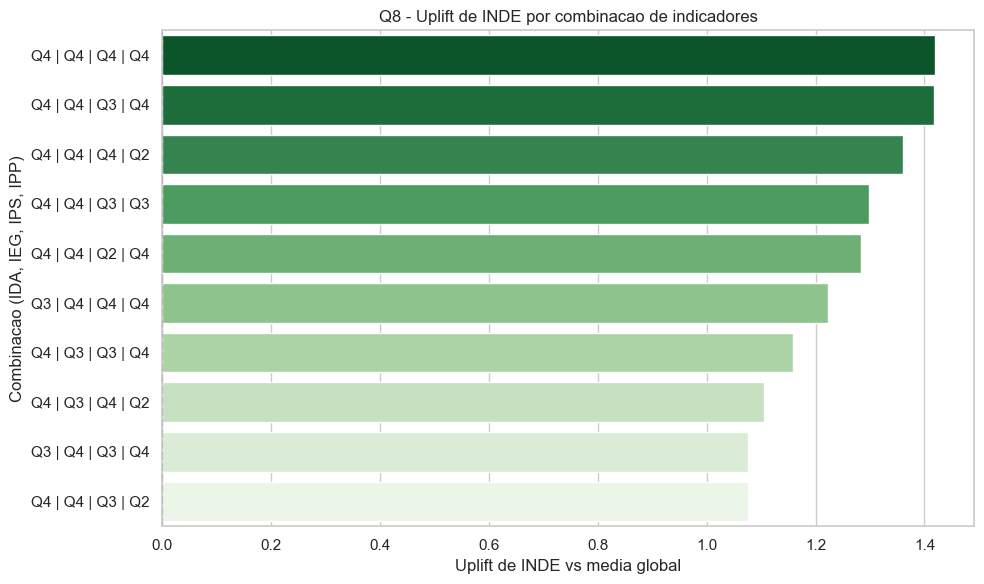

Figura salva: q8_volume_top_combinacoes.png


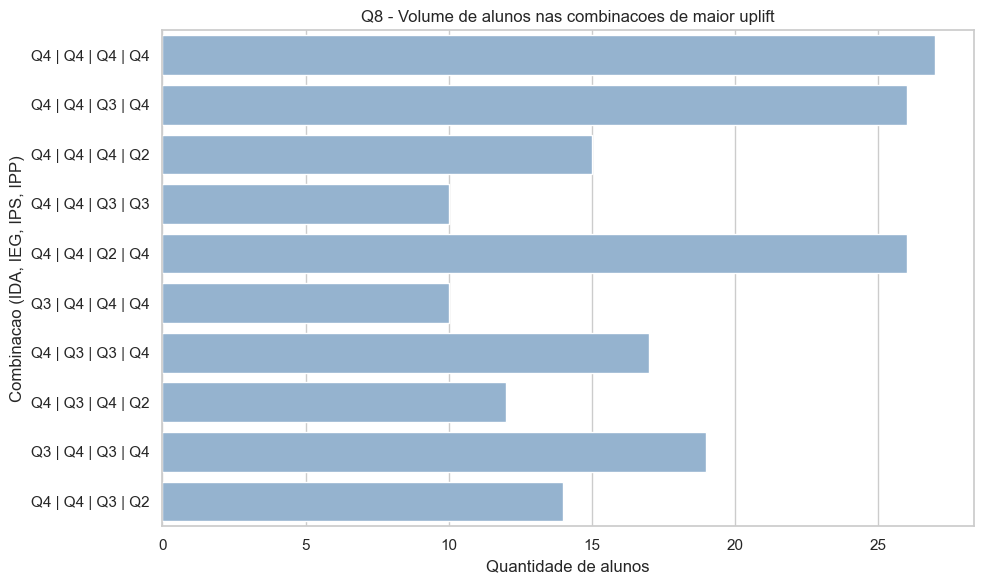


Leitura critica (Q8):
- Achado: combinacoes no quartil superior de multiplos indicadores concentram maior uplift de INDE.
- Impacto: desempenho global emerge de combinacao de fatores, nao de um unico indicador isolado.
- Acao: desenhar intervencoes integradas para elevar simultaneamente IDA, IEG, IPS e IPP.


In [9]:
if {'ano', 'ida', 'ieg', 'ips', 'ipp'}.issubset(df.columns):
    tmp = df.copy()
    mapa_inde = {2022: 'inde_2022', 2023: 'inde_2023', 2024: 'inde_2024'}
    tmp['inde_atual'] = np.nan
    for ano_ref, col in mapa_inde.items():
        if col in tmp.columns:
            tmp.loc[tmp['ano'] == ano_ref, 'inde_atual'] = tmp.loc[tmp['ano'] == ano_ref, col]

    base = tmp.dropna(subset=['inde_atual', 'ida', 'ieg', 'ips', 'ipp']).copy()
    if base.empty:
        print('Sem dados suficientes para Q8 apos filtros de completude.')
    else:
        for c in ['ida', 'ieg', 'ips', 'ipp']:
            base[f'{c}_q'] = pd.qcut(base[c], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')

        group_cols = ['ida_q', 'ieg_q', 'ips_q', 'ipp_q']
        agg = base.groupby(group_cols, dropna=False)['inde_atual'].agg(['count', 'mean']).reset_index()
        agg = agg[agg['count'] >= 10].copy()

        media_global = base['inde_atual'].mean()
        agg['uplift_inde'] = (agg['mean'] - media_global).round(3)
        top10 = agg.sort_values('uplift_inde', ascending=False).head(10)

        print(f'Media global do INDE atual: {media_global:.3f}')
        print('\nTop 10 combinacoes com maior uplift de INDE:')
        print(top10[group_cols + ['count', 'mean', 'uplift_inde']].round(3))

        top10_plot = top10.copy()
        top10_plot['combinacao'] = top10_plot[group_cols].astype(str).agg(' | '.join, axis=1)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=top10_plot, x='uplift_inde', y='combinacao', palette='Greens_r', ax=ax)
        ax.axvline(0, color='black', linestyle='--', alpha=0.7)
        ax.set_title('Q8 - Uplift de INDE por combinacao de indicadores')
        ax.set_xlabel('Uplift de INDE vs media global')
        ax.set_ylabel('Combinacao (IDA, IEG, IPS, IPP)')
        plt.tight_layout()
        salvar_figura(fig, 'q8_uplift_inde_combinacoes.png')
        plt.show()

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=top10_plot, x='count', y='combinacao', color=COR_AZUL_CLARO, ax=ax)
        ax.set_title('Q8 - Volume de alunos nas combinacoes de maior uplift')
        ax.set_xlabel('Quantidade de alunos')
        ax.set_ylabel('Combinacao (IDA, IEG, IPS, IPP)')
        plt.tight_layout()
        salvar_figura(fig, 'q8_volume_top_combinacoes.png')
        plt.show()

        print('\nLeitura critica (Q8):')
        print('- Achado: combinacoes no quartil superior de multiplos indicadores concentram maior uplift de INDE.')
        print('- Impacto: desempenho global emerge de combinacao de fatores, nao de um unico indicador isolado.')
        print('- Acao: desenhar intervencoes integradas para elevar simultaneamente IDA, IEG, IPS e IPP.')
else:
    print('Colunas insuficientes para Q8 (necessario: ano, IDA, IEG, IPS, IPP).')

## Q9: Sinais Precoces de Risco

**Pergunta:** Previsão de risco com Machine Learning: quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?
Construa um modelo preditivo que mostre a probabilidade de o aluno ou aluna entrar em risco de defasagem.

Taxa geral de risco precoce (>=2 flags): 27.69%

Distribuicao do score de risco precoce (0 a 3):
score_risco_precoce
0    28.22
1    44.09
2    23.40
3     4.29
Name: proportion, dtype: float64
Figura salva: q9_distribuicao_score_risco.png


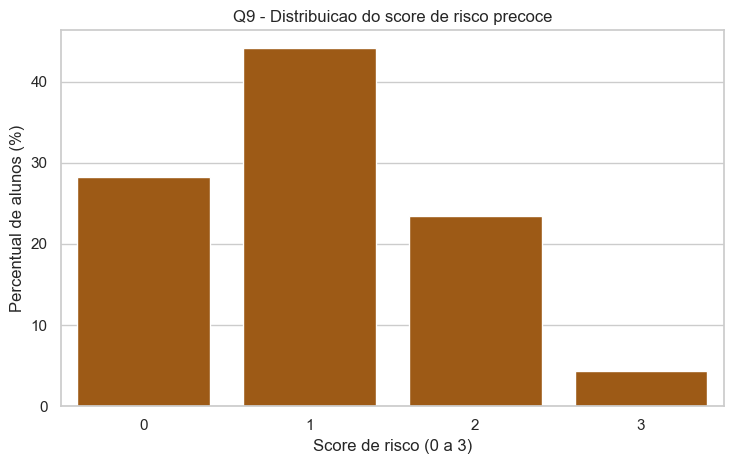


Risco precoce por ano (%):
ano
2022    29.88
2023    36.59
2024    18.25
Name: risco_precoce, dtype: float64
Figura salva: q9_risco_precoce_por_ano.png


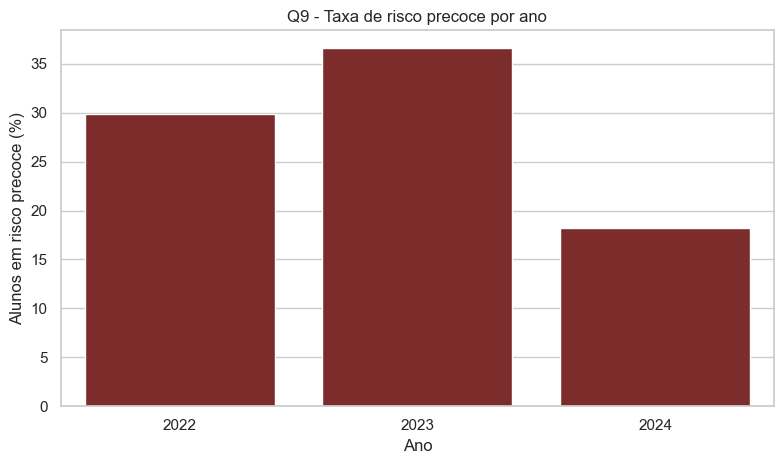

Figura salva: q9_top_fases_risco_precoce.png


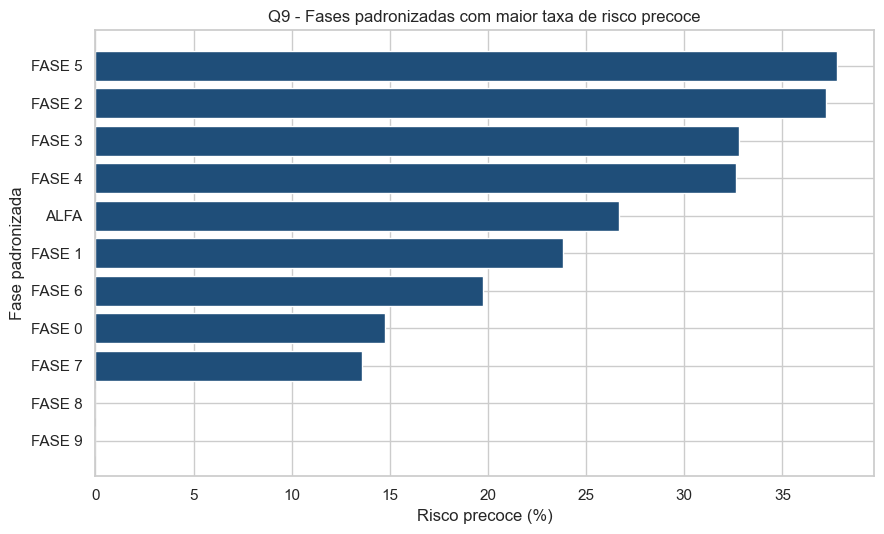


Leitura critica (Q9):
- Achado: parcela relevante da base apresenta sinais precoces multidimensionais de risco.
- Impacto: triagem antecipada pode reduzir defasagem antes da queda forte de desempenho.
- Acao: operacionalizar score de risco em rotina mensal com acao focalizada por fase.


In [16]:
risk_cols = [c for c in ['ian', 'ida', 'ips'] if c in df.columns]
if len(risk_cols) < 3:
    print('Colunas insuficientes para risco precoce (necessario IAN, IDA e IPS).')
else:
    tmp = df.copy()
    fase_col = 'fase_padronizada' if 'fase_padronizada' in tmp.columns else 'phase'
    limiares = {c: tmp[c].quantile(0.25) for c in risk_cols}

    for c in risk_cols:
        tmp[f'flag_{c}_baixo'] = (tmp[c] <= limiares[c]).astype(int)

    tmp['score_risco_precoce'] = tmp[[f'flag_{c}_baixo' for c in risk_cols]].sum(axis=1)
    tmp['risco_precoce'] = (tmp['score_risco_precoce'] >= 2).astype(int)

    taxa = tmp['risco_precoce'].mean() * 100
    print(f'Taxa geral de risco precoce (>=2 flags): {taxa:.2f}%')

    dist_score = tmp['score_risco_precoce'].value_counts(normalize=True).sort_index().mul(100).round(2)
    print('\nDistribuicao do score de risco precoce (0 a 3):')
    print(dist_score)

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    sns.barplot(x=dist_score.index.astype(int), y=dist_score.values, color=COR_LARANJA, ax=ax)
    ax.set_title('Q9 - Distribuicao do score de risco precoce')
    ax.set_xlabel('Score de risco (0 a 3)')
    ax.set_ylabel('Percentual de alunos (%)')
    plt.tight_layout()
    salvar_figura(fig, 'q9_distribuicao_score_risco.png')
    plt.show()

    if tmp['ano'].notna().any():
        risco_ano = tmp.groupby('ano')['risco_precoce'].mean().mul(100).round(2)
        print('\nRisco precoce por ano (%):')
        print(risco_ano)

        fig, ax = plt.subplots(figsize=(8, 4.8))
        sns.barplot(x=risco_ano.index.astype(int), y=risco_ano.values, color=COR_VERMELHO, ax=ax)
        ax.set_title('Q9 - Taxa de risco precoce por ano')
        ax.set_xlabel('Ano')
        ax.set_ylabel('Alunos em risco precoce (%)')
        plt.tight_layout()
        salvar_figura(fig, 'q9_risco_precoce_por_ano.png')
        plt.show()

    if fase_col in tmp.columns:
        risco_fase = (
            tmp[tmp[fase_col].notna()]
            .groupby(fase_col)['risco_precoce']
            .agg(['count', 'mean'])
            .query('count >= 20')
            .sort_values('mean', ascending=False)
            .head(12)
        )
        if not risco_fase.empty:
            fig, ax = plt.subplots(figsize=(9, 5.5))
            ax.barh(risco_fase.index.astype(str), risco_fase['mean'].mul(100).values, color=COR_AZUL)
            ax.invert_yaxis()
            ax.set_title('Q9 - Fases com maior taxa de risco precoce')
            ax.set_xlabel('Risco precoce (%)')
            ax.set_ylabel('Fase')
            plt.tight_layout()
            salvar_figura(fig, 'q9_top_fases_risco_precoce.png')
            plt.show()

    print('\nLeitura critica (Q9):')
    print('- Achado: parcela relevante da base apresenta sinais precoces multidimensionais de risco.')
    print('- Impacto: triagem antecipada pode reduzir defasagem antes da queda forte de desempenho.')
    print('- Acao: operacionalizar score de risco em rotina mensal com acao focalizada por fase.')

## Q10: Evolucao de Desempenho entre Fases

**Pergunta:** Efetividade do programa: os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

INDE medio por ano (todas as fases):
      count   mean    std   ci95
ano                             
2022    860  7.036  1.018  0.068
2023    931  7.342  0.902  0.058
2024   1054  7.397  1.014  0.061
Figura salva: q10_tendencia_inde_ano_ic95.png


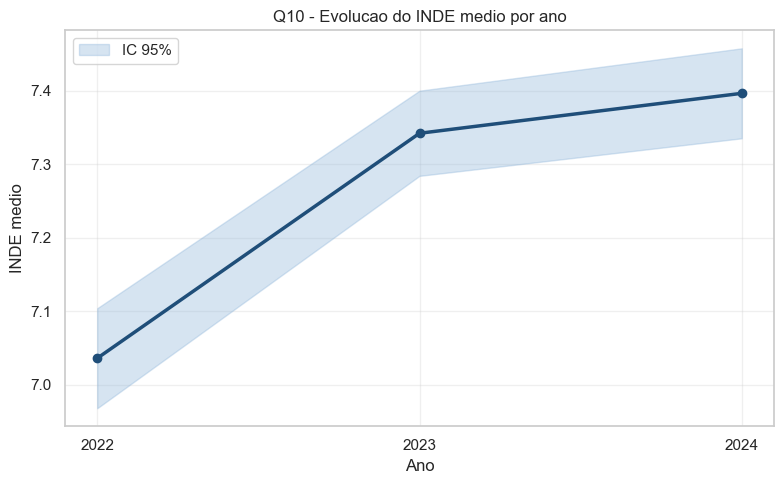


INDE medio por Fase x Ano:
ano                2022   2023   2024
fase_padronizada                     
ALFA                NaN  7.680  7.502
FASE 0            7.366    NaN    NaN
FASE 1            7.200  7.452  7.564
FASE 2            6.959  7.372  7.372
FASE 3            6.600  6.966  7.106
FASE 4            7.005  7.072  7.296
FASE 5            6.875  6.867  7.475
FASE 6            7.201  7.243  7.843
FASE 7            6.635  7.830  7.579
FASE 8              NaN    NaN    NaN
FASE 9              NaN    NaN    NaN
Figura salva: q10_linha_inde_por_fase.png


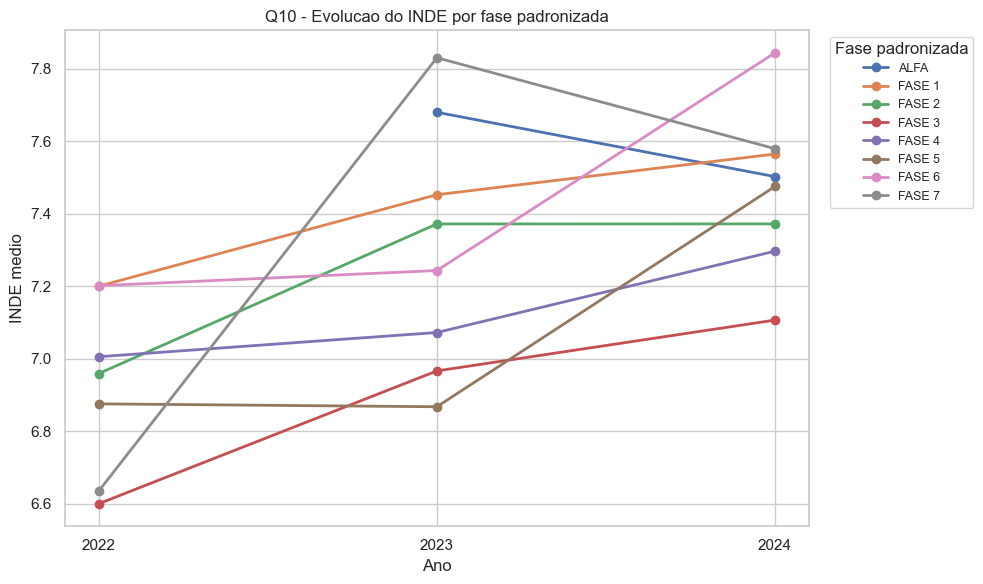

Figura salva: q10_heatmap_inde_fase_ano.png


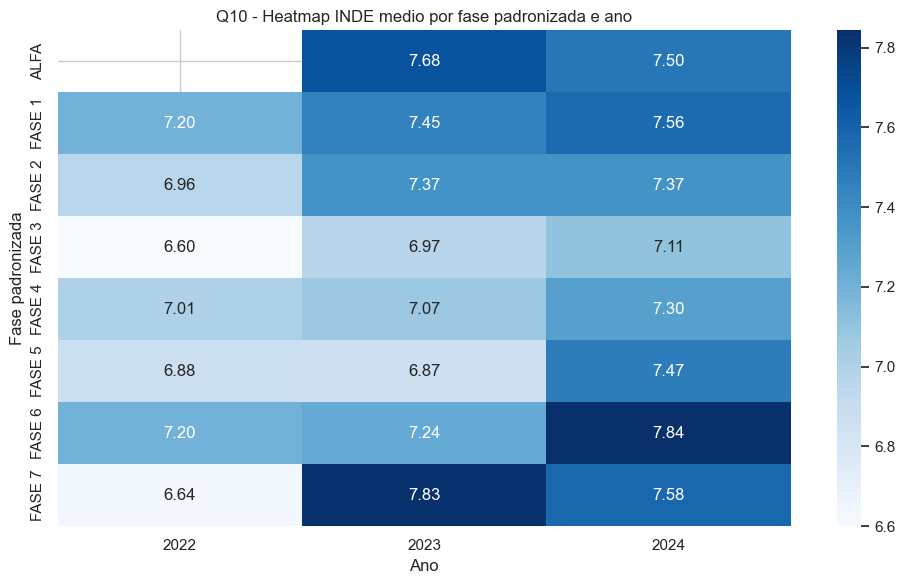

Figura salva: q10_barra_inde_medio_por_fase.png


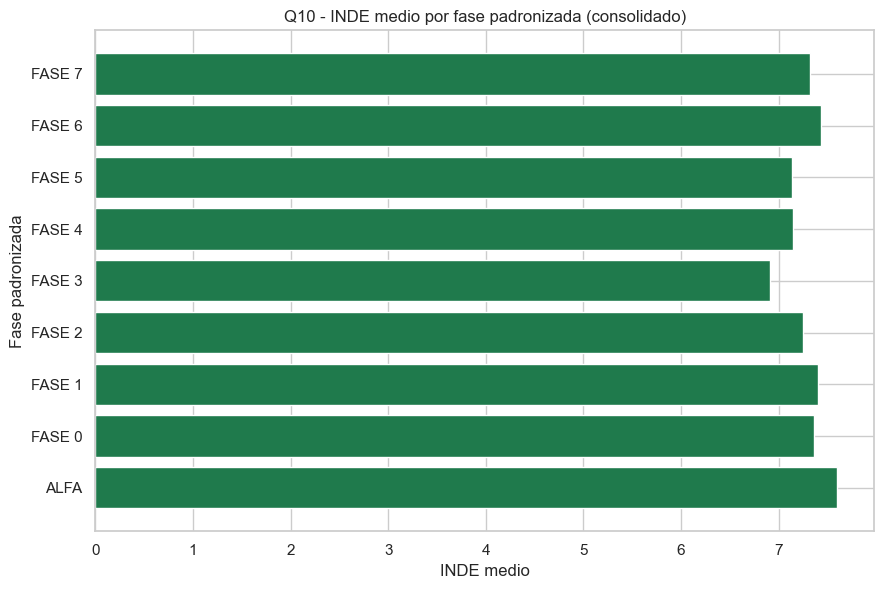


Leitura critica (Q10):
- Achado: variacao acumulada do INDE medio = +0.361 no periodo observado.
- Impacto: melhoria agregada pode esconder heterogeneidade relevante entre fases.
- Acao: monitorar trajetorias por fase com meta anual e intervencao diferencial.


In [17]:
# Q10: Evolucao longitudinal do INDE por fase (foco em leitura para banca)
inde_map = {2022: 'inde_2022', 2023: 'inde_2023', 2024: 'inde_2024'}
available = {k: v for k, v in inde_map.items() if v in df.columns}

if not available or 'ano' not in df.columns:
    print('Dados insuficientes para analise longitudinal.')
else:
    tmp = df.copy()
    fase_col = 'fase_padronizada' if 'fase_padronizada' in tmp.columns else 'phase'
    tmp['inde_atual'] = np.nan
    for ano_ref, col in available.items():
        tmp.loc[tmp['ano'] == ano_ref, 'inde_atual'] = tmp.loc[tmp['ano'] == ano_ref, col]

    trend = (
        tmp.groupby('ano')['inde_atual']
        .agg(['count', 'mean', 'std'])
        .reindex(sorted(available.keys()))
    )
    trend['ci95'] = (1.96 * (trend['std'] / np.sqrt(trend['count']))).fillna(0)
    anos_plot = trend.index.astype(int).tolist()

    print('INDE medio por ano (todas as fases):')
    print(trend.round(3))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(anos_plot, trend['mean'].values, marker='o', linewidth=2.5, color=COR_AZUL)
    ax.fill_between(
        anos_plot,
        (trend['mean'] - trend['ci95']).values,
        (trend['mean'] + trend['ci95']).values,
        color=COR_AZUL_CLARO,
        alpha=0.35,
        label='IC 95%'
    )
    ax.set_title('Q10 - Evolucao do INDE medio por ano')
    ax.set_xlabel('Ano')
    ax.set_ylabel('INDE medio')
    ax.set_xticks(anos_plot)
    ax.set_xticklabels([str(a) for a in anos_plot])
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    salvar_figura(fig, 'q10_tendencia_inde_ano_ic95.png')
    plt.show()

    if fase_col in tmp.columns:
        tmp_fases = tmp[tmp[fase_col].notna()].copy()

        pivot = (
            tmp_fases.groupby([fase_col, 'ano'])['inde_atual']
            .mean()
            .unstack()
            .reindex(columns=sorted(available.keys()))
        )

        def _fase_sort_key(x):
            x = str(x)
            if x.upper() == 'ALFA':
                return (-1, 0)
            m = re.search(r'\d+', x)
            return (0, int(m.group())) if m else (1, 999)

        pivot = pivot.loc[sorted(pivot.index, key=_fase_sort_key)]
        print('\nINDE medio por Fase x Ano:')
        print(pivot.round(3))

        pivot_valid = pivot.dropna(how='all').dropna(thresh=2, axis=0)
        if not pivot_valid.empty:
            fig, ax = plt.subplots(figsize=(10, 6))
            pivot_valid.T.plot(ax=ax, marker='o', linewidth=2)
            ax.set_title('Q10 - Evolucao do INDE por fase')
            ax.set_ylabel('INDE medio')
            ax.set_xlabel('Ano')
            ax.set_xticks(anos_plot)
            ax.set_xticklabels([str(a) for a in anos_plot])
            ax.legend(title='Fase', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
            plt.tight_layout()
            salvar_figura(fig, 'q10_linha_inde_por_fase.png')
            plt.show()

            fig, ax = plt.subplots(figsize=(10, 6))
            sns.heatmap(pivot_valid, annot=True, fmt='.2f', cmap='Blues', ax=ax)
            ax.set_title('Q10 - Heatmap INDE medio por fase e ano')
            ax.set_xlabel('Ano')
            ax.set_ylabel('Fase')
            plt.tight_layout()
            salvar_figura(fig, 'q10_heatmap_inde_fase_ano.png')
            plt.show()
        else:
            print('Serie temporal por fase insuficiente: cada fase aparece em apenas 1 ano.')

        phase_mean = tmp_fases.groupby(fase_col)['inde_atual'].mean()
        phase_mean = phase_mean.loc[sorted(phase_mean.index, key=_fase_sort_key)]
        fig, ax = plt.subplots(figsize=(9, max(5, len(phase_mean) * 0.55)))
        ax.barh(phase_mean.index.astype(str), phase_mean.values, color=COR_VERDE)
        ax.set_title('Q10 - INDE medio por fase (consolidado)')
        ax.set_xlabel('INDE medio')
        ax.set_ylabel('Fase')
        plt.tight_layout()
        salvar_figura(fig, 'q10_barra_inde_medio_por_fase.png')
        plt.show()

    variacao_total = trend['mean'].iloc[-1] - trend['mean'].iloc[0]
    print('\nLeitura critica (Q10):')
    print(f'- Achado: variacao acumulada do INDE medio = {variacao_total:+.3f} no periodo observado.')
    print('- Impacto: melhoria agregada pode esconder heterogeneidade relevante entre fases.')
    print('- Acao: monitorar trajetorias por fase com meta anual e intervencao diferencial.')

## Testes Estatísticos

Validação estatística das diferenças observadas entre grupos (Kruskal-Wallis + Mann-Whitney U; α = 0,05).


In [12]:
from scipy import stats

print('=== TESTES ESTATISTICOS (alpha = 0,05) ===\n')

def _sig(p):
    return 'Significativo' if p < 0.05 else 'Nao significativo'

# INDE por ano
if 'inde_atual' in tmp.columns and 'ano' in tmp.columns:
    groups_yr = [tmp[tmp['ano'] == y]['inde_atual'].dropna() for y in sorted(tmp['ano'].dropna().unique())]
    groups_yr = [g for g in groups_yr if len(g) >= 5]
    if len(groups_yr) >= 2:
        H, p = stats.kruskal(*groups_yr)
        print(f'INDE por ano    - Kruskal-Wallis H={H:.3f}, p={p:.4f} -> {_sig(p)}')

# INDE por fase
if 'phase' in tmp.columns and 'inde_atual' in tmp.columns:
    groups_ph = [tmp[tmp['phase'] == ph]['inde_atual'].dropna() for ph in sorted(tmp['phase'].dropna().unique())]
    groups_ph = [g for g in groups_ph if len(g) >= 5]
    if len(groups_ph) >= 2:
        H, p = stats.kruskal(*groups_ph)
        print(f'INDE por fase   - Kruskal-Wallis H={H:.3f}, p={p:.4f} -> {_sig(p)}')

# IAN por ano
if {'ian', 'ano'}.issubset(df.columns):
    groups_ian = [df[df['ano'] == y]['ian'].dropna() for y in sorted(df['ano'].dropna().unique())]
    groups_ian = [g for g in groups_ian if len(g) >= 5]
    if len(groups_ian) >= 2:
        H, p = stats.kruskal(*groups_ian)
        print(f'IAN por ano     - Kruskal-Wallis H={H:.3f}, p={p:.4f} -> {_sig(p)}')

# IDA por ano
if {'ida', 'ano'}.issubset(df.columns):
    groups_ida = [df[df['ano'] == y]['ida'].dropna() for y in sorted(df['ano'].dropna().unique())]
    groups_ida = [g for g in groups_ida if len(g) >= 5]
    if len(groups_ida) >= 2:
        H, p = stats.kruskal(*groups_ida)
        print(f'IDA por ano     - Kruskal-Wallis H={H:.3f}, p={p:.4f} -> {_sig(p)}')

# IDA: alta IAA vs baixa IAA (mediana)
if {'iaa', 'ida'}.issubset(df.columns):
    med = df['iaa'].median()
    g1 = df[df['iaa'] >= med]['ida'].dropna()
    g2 = df[df['iaa'] < med]['ida'].dropna()
    if len(g1) >= 5 and len(g2) >= 5:
        U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f'IDA alta-IAA vs baixa-IAA - Mann-Whitney U={U:.0f}, p={p:.4f} -> {_sig(p)}')

# IDA: IPS-Q1 vs restante
if {'ips', 'ida'}.issubset(df.columns):
    q1_ips = df['ips'].quantile(0.25)
    g1 = df[df['ips'] <= q1_ips]['ida'].dropna()
    g2 = df[df['ips'] > q1_ips]['ida'].dropna()
    if len(g1) >= 5 and len(g2) >= 5:
        U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f'IDA IPS-Q1 vs restante    - Mann-Whitney U={U:.0f}, p={p:.4f} -> {_sig(p)}')

=== TESTES ESTATISTICOS (alpha = 0,05) ===

INDE por ano    - Kruskal-Wallis H=64.678, p=0.0000 -> Significativo
INDE por fase   - Kruskal-Wallis H=358.403, p=0.0000 -> Significativo
IAN por ano     - Kruskal-Wallis H=123.679, p=0.0000 -> Significativo
IDA por ano     - Kruskal-Wallis H=26.551, p=0.0000 -> Significativo
IDA alta-IAA vs baixa-IAA - Mann-Whitney U=1147994, p=0.0000 -> Significativo
IDA IPS-Q1 vs restante    - Mann-Whitney U=712624, p=0.0053 -> Significativo


## Q11: Insights Integrados

**Pergunta:** Insights e criatividade: você pode adicionar mais insights e pontos de vista não abordados nas perguntas;
utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.

In [13]:
# Q11: Resumo executivo integrado
print('=== RESUMO EXECUTIVO - INSIGHTS INTEGRADOS ===\n')

insights = []

# Tendência IAN
if {'ian', 'ano'}.issubset(df.columns):
    s = df.groupby('ano')['ian'].mean().sort_index()
    if len(s) >= 2:
        delta = s.iloc[-1] - s.iloc[0]
        direction = 'melhora' if delta > 0 else ('piora' if delta < 0 else 'estabilidade')
        insights.append(f'IAN: variacao {delta:+.3f} entre {int(s.index[0])} e {int(s.index[-1])} ({direction})')

# Tendência IDA
if {'ida', 'ano'}.issubset(df.columns):
    s = df.groupby('ano')['ida'].mean().sort_index()
    if len(s) >= 2:
        delta = s.iloc[-1] - s.iloc[0]
        direction = 'melhora' if delta > 0 else ('piora' if delta < 0 else 'estabilidade')
        insights.append(f'IDA: variacao {delta:+.3f} entre {int(s.index[0])} e {int(s.index[-1])} ({direction})')

# Correlação IAA × IDA
if {'iaa', 'ida'}.issubset(df.columns):
    r = df[['iaa', 'ida']].corr().iloc[0, 1]
    force = 'forte' if abs(r) > 0.6 else ('moderada' if abs(r) > 0.3 else 'fraca')
    insights.append(f'Correlacao IAA x IDA = {r:.3f} (associacao {force})')

# Correlação IEG
if {'ieg', 'ida', 'ipv'}.issubset(df.columns):
    r_ida = df[['ieg', 'ida']].corr().iloc[0, 1]
    r_ipv = df[['ieg', 'ipv']].corr().iloc[0, 1]
    insights.append(f'IEG correlaciona com IDA ({r_ida:.3f}) e IPV ({r_ipv:.3f})')

# Melhores preditores do IPV
if 'ipv' in df.columns:
    num_c = [c for c in df.select_dtypes(include='number').columns if c not in ['ipv', 'ano']]
    if num_c:
        top3 = df[num_c + ['ipv']].corr(numeric_only=True)['ipv'].drop('ipv').abs().nlargest(3)
        insights.append('Principais variaveis associadas ao IPV: ' + ', '.join(f'{c} ({v:.3f})' for c, v in top3.items()))

# Impacto do IPS sobre IDA
if {'ips', 'ida'}.issubset(df.columns):
    q1_ips = df['ips'].quantile(0.25)
    ida_q1 = df[df['ips'] <= q1_ips]['ida'].mean()
    ida_rest = df[df['ips'] > q1_ips]['ida'].mean()
    diff = ida_q1 - ida_rest
    insights.append(f'Alunos IPS no Q1: IDA medio {ida_q1:.3f} vs {ida_rest:.3f} (diferenca {diff:+.3f})')

# Taxa de risco precoce multidimensional
if {'ian', 'ida', 'ips'}.issubset(df.columns):
    risk_flags = sum([
        (df['ian'] <= df['ian'].quantile(0.25)).astype(int),
        (df['ida'] <= df['ida'].quantile(0.25)).astype(int),
        (df['ips'] <= df['ips'].quantile(0.25)).astype(int),
    ])
    taxa = (risk_flags >= 2).mean() * 100
    insights.append(f'Taxa de risco precoce multidimensional (>=2 indicadores no Q1): {taxa:.1f}%')

for i, ins in enumerate(insights, 1):
    print(f'{i:2d}. {ins}')

=== RESUMO EXECUTIVO - INSIGHTS INTEGRADOS ===

 1. IAN: variacao +1.259 entre 2022 e 2024 (melhora)
 2. IDA: variacao +0.259 entre 2022 e 2024 (melhora)
 3. Correlacao IAA x IDA = 0.115 (associacao fraca)
 4. IEG correlaciona com IDA (0.539) e IPV (0.558)
 5. Principais variaveis associadas ao IPV: inde_2024 (0.758), inde_2022 (0.621), ipp (0.607)
 6. Alunos IPS no Q1: IDA medio 6.259 vs 6.417 (diferenca -0.158)
 7. Taxa de risco precoce multidimensional (>=2 indicadores no Q1): 27.7%
